The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


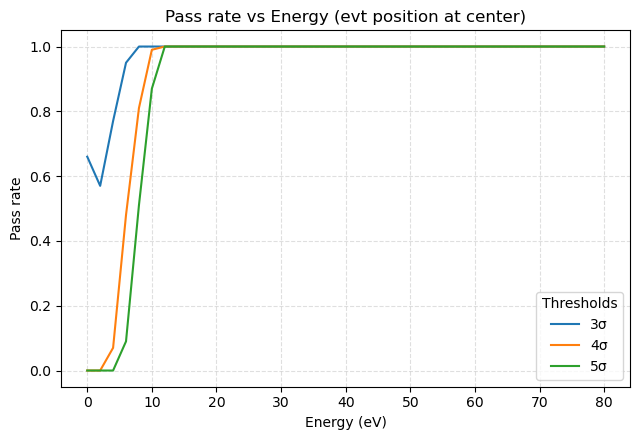


Pass rates:
Energy           3σ          4σ          5σ
0            0.6600     0.0000     0.0000
2            0.5700     0.0000     0.0000
4            0.7700     0.0700     0.0000
6            0.9500     0.4800     0.0900
8            1.0000     0.8100     0.5100
10           1.0000     0.9900     0.8700
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000
22           1.0000     1.0000     1.0000
24           1.0000     1.0000     1.0000
26           1.0000     1.0000     1.0000
28           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
32           1.0000     1.0000     1.0000
34           1.0000     1.0000     1.0000
36           1.0000     1.0000     1.0000
38           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
42           1.0000     1.0000     1.0000
44           1.0000

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k_80ev/indiv_max_amp")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (evt position at center)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


[warn] missing file: ../pt_max_amp/pt_energy_1.npy
[warn] missing file: ../pt_max_amp/pt_energy_3.npy
[warn] missing file: ../pt_max_amp/pt_energy_5.npy
[warn] missing file: ../pt_max_amp/pt_energy_7.npy
[warn] missing file: ../pt_max_amp/pt_energy_9.npy
[warn] missing file: ../pt_max_amp/pt_energy_11.npy
[warn] missing file: ../pt_max_amp/pt_energy_13.npy
[warn] missing file: ../pt_max_amp/pt_energy_15.npy
[warn] missing file: ../pt_max_amp/pt_energy_17.npy
[warn] missing file: ../pt_max_amp/pt_energy_19.npy
[warn] missing file: ../pt_max_amp/pt_energy_21.npy
[warn] missing file: ../pt_max_amp/pt_energy_23.npy
[warn] missing file: ../pt_max_amp/pt_energy_25.npy
[warn] missing file: ../pt_max_amp/pt_energy_27.npy
[warn] missing file: ../pt_max_amp/pt_energy_29.npy
[warn] missing file: ../pt_max_amp/pt_energy_31.npy
[warn] missing file: ../pt_max_amp/pt_energy_33.npy
[warn] missing file: ../pt_max_amp/pt_energy_35.npy
[warn] missing file: ../pt_max_amp/pt_energy_37.npy
[warn] missing fi

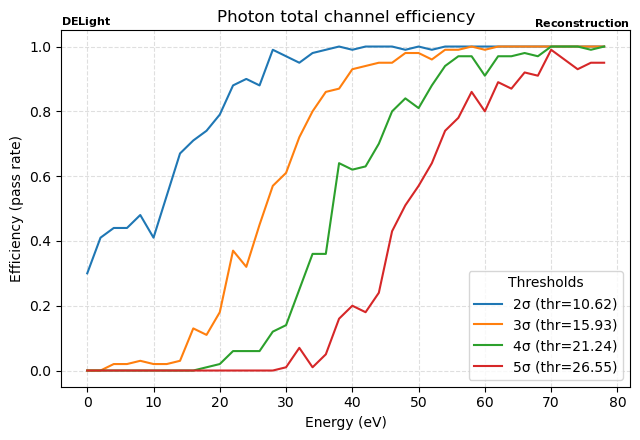


Pass rates:
Energy    2σ(thr=10.62)   3σ(thr=15.93)   4σ(thr=21.24)   5σ(thr=26.55)
0                0.3000         0.0000         0.0000         0.0000
2                0.4100         0.0000         0.0000         0.0000
4                0.4400         0.0200         0.0000         0.0000
6                0.4400         0.0200         0.0000         0.0000
8                0.4800         0.0300         0.0000         0.0000
10               0.4100         0.0200         0.0000         0.0000
12               0.5400         0.0200         0.0000         0.0000
14               0.6700         0.0300         0.0000         0.0000
16               0.7100         0.1300         0.0000         0.0000
18               0.7400         0.1100         0.0100         0.0000
20               0.7900         0.1800         0.0200         0.0000
22               0.8800         0.3700         0.0600         0.0000
24               0.9000         0.3200         0.0600         0.0000
26               0

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
base = Path("../pt_max_amp")
file_tmpl = "pt_energy_{E}.npy"
energies = range(0, 80)                # 0..20 inclusive
sigma = 5.31
sigma_multiples = [2, 3, 4, 5]         # thresholds in units of sigma

# --- Thresholds dict in your style ---
thresholds = {k: k * sigma for k in sigma_multiples}

# --- Collect pass rates per energy ---
available_E = []
pass_rates = {k: [] for k in sigma_multiples}

def load_first_column(path: Path):
    arr = np.load(path)
    if arr.ndim == 2 and arr.shape[1] >= 1:
        return arr[:, 0]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected shape {arr.shape} in {path}")

for E in energies:
    fpath = base / file_tmpl.format(E=E)
    try:
        amps = load_first_column(fpath)
    except FileNotFoundError:
        print(f"[warn] missing file: {fpath}")
        continue

    available_E.append(E)
    for k in sigma_multiples:
        thr = thresholds[k]
        rate = (amps >= thr).mean()  # use '>' if you prefer strict
        pass_rates[k].append(rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for k in sigma_multiples:
    thr = thresholds[k]
    label = f"{k}σ (thr={thr:.2f})"
    plt.plot(available_E, pass_rates[k], label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency (pass rate)")
plt.title("Photon total channel efficiency")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")

# Add "shoulder" labels
ax = plt.gca()
ax.text(0.0, 1.005, r"$\mathbf{DELight}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
ax.text(1.0, 1.005, r"$\mathbf{Reconstruction}$",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{k}σ(thr={thresholds[k]:.2f})".rjust(14) for k in sigma_multiples])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for k in sigma_multiples:
        row.append(f"{pass_rates[k][i]:>14.4f}")
    print(" ".join(row))


In [2]:
import os
print("os.cpu_count():", os.cpu_count())


os.cpu_count(): 128


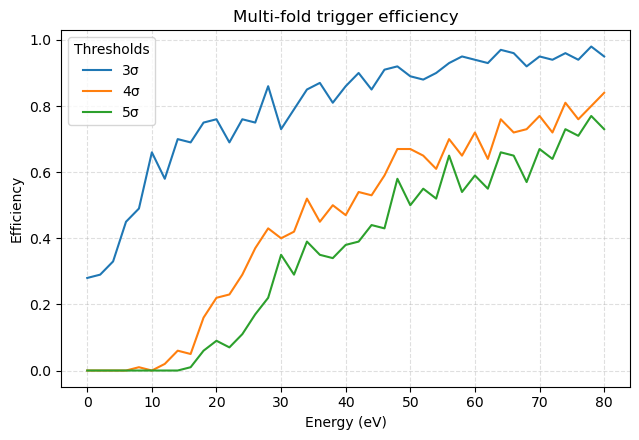


Pass rates (2nd-highest channel ≥ threshold):
Energy           3σ          4σ          5σ
0            0.2800     0.0000     0.0000
2            0.2900     0.0000     0.0000
4            0.3300     0.0000     0.0000
6            0.4500     0.0000     0.0000
8            0.4900     0.0100     0.0000
10           0.6600     0.0000     0.0000
12           0.5800     0.0200     0.0000
14           0.7000     0.0600     0.0000
16           0.6900     0.0500     0.0100
18           0.7500     0.1600     0.0600
20           0.7600     0.2200     0.0900
22           0.6900     0.2300     0.0700
24           0.7600     0.2900     0.1100
26           0.7500     0.3700     0.1700
28           0.8600     0.4300     0.2200
30           0.7300     0.4000     0.3500
32           0.7900     0.4200     0.2900
34           0.8500     0.5200     0.3900
36           0.8700     0.4500     0.3500
38           0.8100     0.5000     0.3400
40           0.8600     0.4700     0.3800
42           0.9000     0.5

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/v2_300k_80ev_rand/indiv_max_amp")
thresholds = [2.30, 3.07, 3.84]   # pass if 2nd-largest channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)

# --- Compute pass rates (using 2nd-largest across 56 channels) ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)

    # 2nd-largest value per repeat:
    # For small arrays (100x56), full sort is simple & clear.
    second_largest = np.sort(data, axis=1)[:, -2]  # shape (R,)

    for thr in thresholds:
        passes = second_largest >= thr
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Multi-fold trigger efficiency")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates (2nd-highest channel ≥ threshold):")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


[warn] Missing file (pt): ../pt_max_amp/pt_energy_1.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_3.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_5.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_7.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_9.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_11.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_13.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_15.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_17.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_19.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_21.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_23.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_25.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_27.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_29.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_31.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_33.npy
[warn] Missing file (pt): ../pt_max_

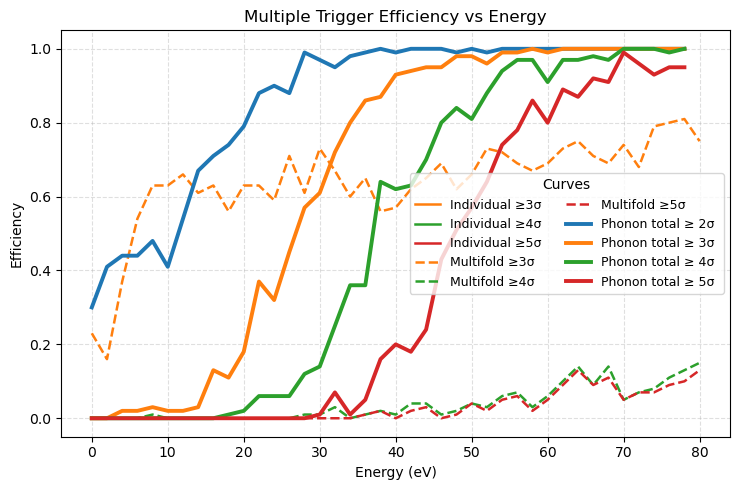


Individual (ANY channel ≥ thr): (no data)

Multifold (2nd-largest ≥ thr):
Energy               3σ           4σ           5σ  
0                 0.2300      0.0000      0.0000
2                 0.1600      0.0000      0.0000
4                 0.3700      0.0000      0.0000
6                 0.5400      0.0000      0.0000
8                 0.6300      0.0100      0.0000
10                0.6300      0.0000      0.0000
12                0.6600      0.0000      0.0000
14                0.6100      0.0000      0.0000
16                0.6300      0.0000      0.0000
18                0.5600      0.0000      0.0000
20                0.6300      0.0000      0.0000
22                0.6300      0.0000      0.0000
24                0.5900      0.0000      0.0000
26                0.7100      0.0000      0.0000
28                0.6100      0.0100      0.0000
30                0.7300      0.0100      0.0000
32                0.6700      0.0300      0.0000
34                0.6000      0.0000    

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import defaultdict

# =========================
# Common style & helpers
# =========================
# Consistent colors per sigma level (2σ..5σ)
sigma_colors = {
    2: "C0",
    3: "C1",
    4: "C2",
    5: "C3",
}
# For the 3–5σ thresholds expressed as absolute values
abs_thr_to_sigma = {2.30: 3, 3.07: 4, 3.84: 5}

def safe_load_npy(path: Path):
    if not path.exists():
        raise FileNotFoundError(str(path))
    return np.load(path)

def find_energies_from_glob(base: Path, pattern: str, group_re=r"energy_(\d+)"):
    es = []
    for f in base.glob(pattern):
        m = re.search(group_re, f.name)
        if m:
            es.append(int(m.group(1)))
    return sorted(set(es))

# ==========================================
# A) Individual-channel trigger (solid line)
#    Pass if ANY channel >= threshold
# ==========================================
indiv = {
    "base_dir": Path("../wk20/max_amp_400"),
    "file_tmpl": "max_amplitudes_energy_{E}.npy",
    "thresholds_abs": [2.30, 3.07, 3.84],   # 3σ, 4σ, 5σ
    "label_prefix": "Individual ≥",
}
indiv["energies"] = find_energies_from_glob(indiv["base_dir"], "max_amplitudes_energy_*.npy")

indiv_available_E = []
indiv_pass_rates = {thr: [] for thr in indiv["thresholds_abs"]}

for E in indiv["energies"]:
    path = indiv["base_dir"] / indiv["file_tmpl"].format(E=E)
    try:
        data = safe_load_npy(path)  # expected shape (R, 56)
    except FileNotFoundError:
        print(f"[warn] Missing file (individual): {path}")
        continue
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"[individual] Unexpected shape in {path}: {data.shape} (expected (R,56))")

    indiv_available_E.append(E)
    # Pass if ANY channel >= threshold
    for thr in indiv["thresholds_abs"]:
        passes = (data >= thr).any(axis=1)
        indiv_pass_rates[thr].append(passes.mean())

# ==========================================
# B) Multi-fold trigger (dashed line)
#    Pass if 2nd-largest channel >= threshold
# ==========================================
multi = {
    "base_dir": Path("/ceph/dwong/trigger_samples/v2_300k_80ev/indiv_max_amp"),
    "file_tmpl": "max_amplitudes_energy_{E}.npy",
    "thresholds_abs": [2.30, 3.07, 3.84],  # 3σ, 4σ, 5σ
    "label_prefix": "Multifold ≥",
}
multi["energies"] = find_energies_from_glob(multi["base_dir"], "max_amplitudes_energy_*.npy")

multi_available_E = []
multi_pass_rates = {thr: [] for thr in multi["thresholds_abs"]}

for E in multi["energies"]:
    path = multi["base_dir"] / multi["file_tmpl"].format(E=E)
    try:
        data = safe_load_npy(path)  # expected shape (R, 56)
    except FileNotFoundError:
        print(f"[warn] Missing file (multifold): {path}")
        continue
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"[multifold] Unexpected shape in {path}: {data.shape} (expected (R,56))")

    multi_available_E.append(E)
    second_largest = np.sort(data, axis=1)[:, -2]
    for thr in multi["thresholds_abs"]:
        multi_pass_rates[thr].append((second_largest >= thr).mean())

# ==========================================
# C) Photon total channel (dash-dot line)
#    File layout: first column amplitudes per event
#    thresholds = k * sigma, k in {2,3,4,5}
# ==========================================
pt = {
    "base": Path("../pt_max_amp"),
    "file_tmpl": "pt_energy_{E}.npy",
    "energies": range(0, 80),  # or adjust range as needed
    "sigma": 5.31,
    "sigma_levels": [2, 3, 4, 5],
    "label_prefix": "Phonon total ≥ ",
}

pt_thresholds = {k: k * pt["sigma"] for k in pt["sigma_levels"]}
pt_available_E = []
pt_pass_rates = {k: [] for k in pt["sigma_levels"]}

def load_first_column(path: Path):
    arr = safe_load_npy(path)
    if arr.ndim == 2 and arr.shape[1] >= 1:
        return arr[:, 0]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"[pt] Unexpected shape {arr.shape} in {path}")

for E in pt["energies"]:
    fpath = pt["base"] / pt["file_tmpl"].format(E=E)
    try:
        amps = load_first_column(fpath)
    except FileNotFoundError:
        print(f"[warn] Missing file (pt): {fpath}")
        continue

    pt_available_E.append(E)
    for k in pt["sigma_levels"]:
        thr = pt_thresholds[k]
        pt_pass_rates[k].append((amps >= thr).mean())

# =========================
# Unified Plot
# =========================
plt.figure(figsize=(7.5, 5.0))

# Map abs thresholds to sigma (for colors/labels)
def thr_label_sigma(thr_abs):
    s = abs_thr_to_sigma.get(thr_abs, None)
    return f"{s}σ" if s is not None else f"thr={thr_abs:g}"

# A) Individual (solid)
for thr in indiv["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(
        indiv_available_E,
        indiv_pass_rates[thr],
        linestyle="-",
        linewidth=1.8,
        label=f"{indiv['label_prefix']}{thr_label_sigma(thr)}",
        color=color,
    )

# B) Multifold (dashed)
for thr in multi["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(
        multi_available_E,
        multi_pass_rates[thr],
        linestyle="--",
        linewidth=1.8,
        label=f"{multi['label_prefix']}{thr_label_sigma(thr)}",
        color=color,
    )

# C) Photon total (dash-dot), includes 2σ as well
for k in pt["sigma_levels"]:
    color = sigma_colors.get(k, None)
    plt.plot(
        pt_available_E,
        pt_pass_rates[k],
        linestyle="-",       # dash-dot
        linewidth=2.8,
        label=f"{pt['label_prefix']}{k}σ ",
        color=color,
    )

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Multiple Trigger Efficiency vs Energy")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Curves", ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# =========================
# Optional: quick tables
# =========================
def print_table(title, energies, pr_dict, key_to_str):
    if not energies:
        print(f"\n{title}: (no data)")
        return
    print(f"\n{title}:")
    headers = ["Energy"] + [key_to_str(k).rjust(10) for k in pr_dict.keys()]
    print(" ".join(h.ljust(12) for h in headers))
    for i, E in enumerate(energies):
        row = [f"{E:<12}"]
        for k in pr_dict.keys():
            row.append(f"{pr_dict[k][i]:>12.4f}")
        print("".join(row))

print_table(
    "Individual (ANY channel ≥ thr)",
    indiv_available_E,
    {thr: indiv_pass_rates[thr] for thr in indiv["thresholds_abs"]},
    lambda thr: thr_label_sigma(thr)
)

print_table(
    "Multifold (2nd-largest ≥ thr)",
    multi_available_E,
    {thr: multi_pass_rates[thr] for thr in multi["thresholds_abs"]},
    lambda thr: thr_label_sigma(thr)
)

print_table(
    "Phonon total channel ≥ (kσ)",
    pt_available_E,
    {k: pt_pass_rates[k] for k in pt["sigma_levels"]},
    lambda k: f"{k}σ"
)


[warn] Missing file (pt): ../pt_max_amp/pt_energy_1.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_3.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_5.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_7.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_9.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_11.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_13.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_15.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_17.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_19.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_21.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_23.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_25.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_27.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_29.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_31.npy
[warn] Missing file (pt): ../pt_max_amp/pt_energy_33.npy
[warn] Missing file (pt): ../pt_max_

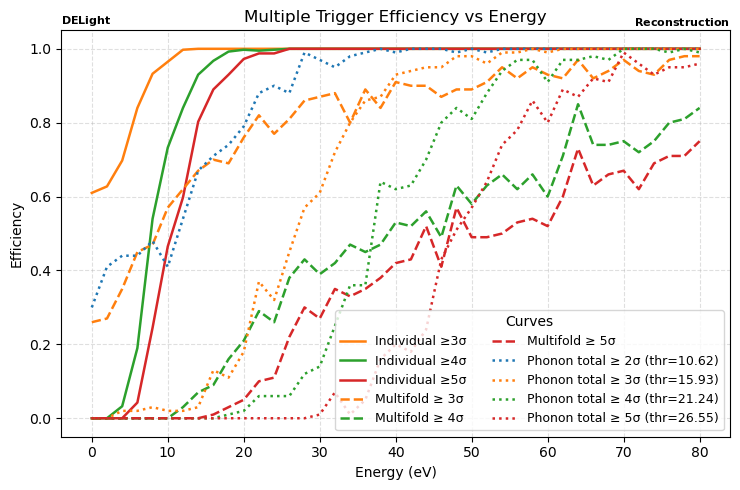

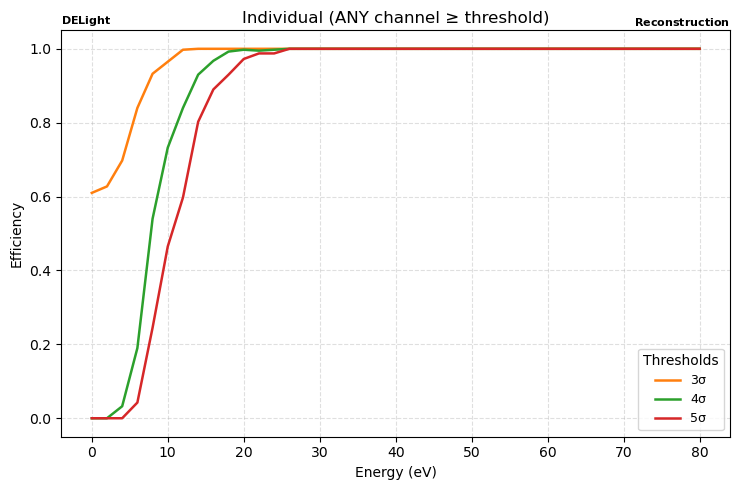

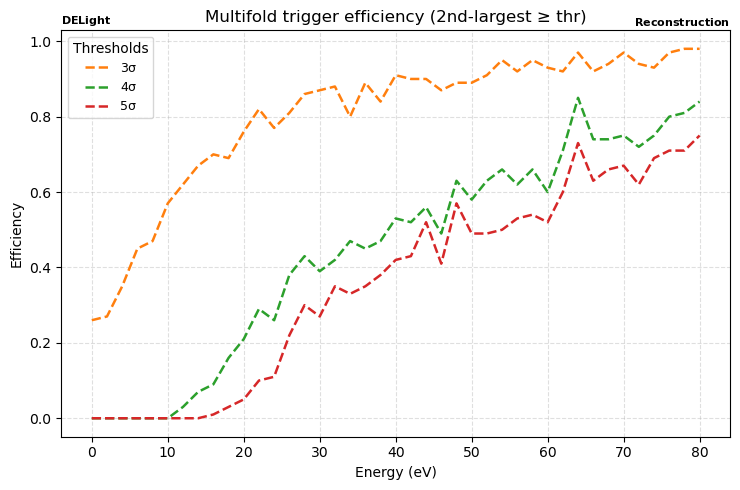

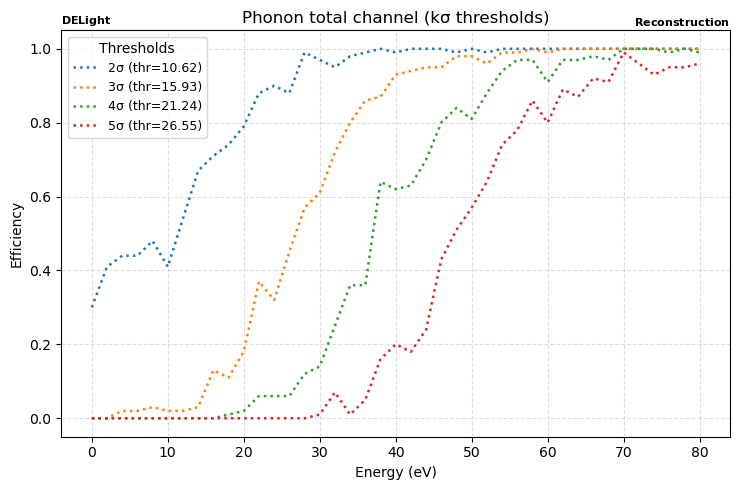

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import defaultdict

# =========================
# Common style & helpers
# =========================
sigma_colors = {  # consistent across all plots
    2: "C0",
    3: "C1",
    4: "C2",
    5: "C3",
}
abs_thr_to_sigma = {2.30: 3, 3.07: 4, 3.84: 5}

def safe_load_npy(path: Path):
    if not path.exists():
        raise FileNotFoundError(str(path))
    return np.load(path)

def find_energies_from_glob(base: Path, pattern: str, group_re=r"energy_(\d+)"):
    es = []
    for f in base.glob(pattern):
        m = re.search(group_re, f.name)
        if m:
            es.append(int(m.group(1)))
    return sorted(set(es))

def add_shoulders(ax):
    ax.text(0.0, 1.005, r"$\mathbf{DELight}$",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
    ax.text(1.0, 1.005, r"$\mathbf{Reconstruction}$",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

# ==========================================
# A) Individual-channel trigger (solid line)
#    Pass if ANY channel >= threshold
# ==========================================
indiv = {
    "base_dir_low": Path("../wk20/max_amp_400"),
    "base_dir_high": Path("/ceph/dwong/trigger_samples/v2_300k_80ev/indiv_max_amp"),
    "file_tmpl": "max_amplitudes_energy_{E}.npy",
    "thresholds_abs": [2.30, 3.07, 3.84],   # 3σ, 4σ, 5σ
    "label_prefix": "Individual ≥",
}

# energies from both ranges
energies_low  = find_energies_from_glob(indiv["base_dir_low"],  indiv["file_tmpl"].format(E="*"))
energies_high = find_energies_from_glob(indiv["base_dir_high"], indiv["file_tmpl"].format(E="*"))
indiv["energies"] = sorted(set(energies_low) | set(energies_high))

indiv_available_E = []
indiv_pass_rates = {thr: [] for thr in indiv["thresholds_abs"]}

for E in indiv["energies"]:
    # decide which base_dir to use
    if E <= 48:
        path = indiv["base_dir_low"] / indiv["file_tmpl"].format(E=E)
    else:
        path = indiv["base_dir_high"] / indiv["file_tmpl"].format(E=E)

    try:
        data = safe_load_npy(path)  # expected shape (R, 56)
    except FileNotFoundError:
        print(f"[warn] Missing file (individual): {path}")
        continue

    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"[individual] Unexpected shape in {path}: {data.shape} (expected (R,56))")

    indiv_available_E.append(E)
    for thr in indiv["thresholds_abs"]:
        passes = (data >= thr).any(axis=1)
        indiv_pass_rates[thr].append(passes.mean())


# ==========================================
# B) Multi-fold trigger (dashed line)
#    Pass if 2nd-largest channel >= threshold
# ==========================================
multi = {
    "base_dir": Path("/ceph/dwong/trigger_samples/v2_300k_80ev/indiv_max_amp"),
    "file_tmpl": "max_amplitudes_energy_{E}.npy",
    "thresholds_abs": [2.30, 3.07, 3.84],  # 3σ, 4σ, 5σ
    "label_prefix": "Multifold ≥ ",
}
multi["energies"] = find_energies_from_glob(multi["base_dir"], "max_amplitudes_energy_*.npy")

multi_available_E = []
multi_pass_rates = {thr: [] for thr in multi["thresholds_abs"]}

for E in multi["energies"]:
    path = multi["base_dir"] / multi["file_tmpl"].format(E=E)
    try:
        data = safe_load_npy(path)  # expected shape (R, 56)
    except FileNotFoundError:
        print(f"[warn] Missing file (multifold): {path}")
        continue
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"[multifold] Unexpected shape in {path}: {data.shape} (expected (R,56))")

    multi_available_E.append(E)
    second_largest = np.sort(data, axis=1)[:, -2]
    for thr in multi["thresholds_abs"]:
        multi_pass_rates[thr].append((second_largest >= thr).mean())

# ==========================================
# C) Photon total channel (dash-dot line)
#    thresholds = k * sigma, k in {2,3,4,5}
# ==========================================
pt = {
    "base": Path("../pt_max_amp"),
    "file_tmpl": "pt_energy_{E}.npy",
    "energies": range(0, 81),
    "sigma": 5.31,
    "sigma_levels": [2, 3, 4, 5],
    "label_prefix": "Phonon total ≥ ",
}
pt_thresholds = {k: k * pt["sigma"] for k in pt["sigma_levels"]}
pt_available_E = []
pt_pass_rates = {k: [] for k in pt["sigma_levels"]}

def load_first_column(path: Path):
    arr = safe_load_npy(path)
    if arr.ndim == 2 and arr.shape[1] >= 1:
        return arr[:, 0]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"[pt] Unexpected shape {arr.shape} in {path}")

for E in pt["energies"]:
    fpath = pt["base"] / pt["file_tmpl"].format(E=E)
    try:
        amps = load_first_column(fpath)
    except FileNotFoundError:
        print(f"[warn] Missing file (pt): {fpath}")
        continue

    pt_available_E.append(E)
    for k in pt["sigma_levels"]:
        thr = pt_thresholds[k]
        pt_pass_rates[k].append((amps >= thr).mean())

# =========================
# Unified Plot (all curves)
# =========================
plt.figure(figsize=(7.5, 5.0))

def thr_label_sigma(thr_abs):
    s = abs_thr_to_sigma.get(thr_abs, None)
    return f"{s}σ" if s is not None else f"thr={thr_abs:g}"

# A) Individual (solid)
for thr in indiv["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(
        indiv_available_E, indiv_pass_rates[thr],
        linestyle="-", linewidth=1.8,
        label=f"{indiv['label_prefix']}{thr_label_sigma(thr)}",
        color=color,
    )

# B) Multifold (dashed)
for thr in multi["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(
        multi_available_E, multi_pass_rates[thr],
        linestyle="--", linewidth=1.8,
        label=f"{multi['label_prefix']}{thr_label_sigma(thr)}",
        color=color,
    )

# C) Phonon total (dash-dot)
for k in pt["sigma_levels"]:
    color = sigma_colors.get(k, None)
    plt.plot(
        pt_available_E, pt_pass_rates[k],
        linestyle="dotted", linewidth=1.8,
        label=f"{pt['label_prefix']}{k}σ (thr={pt_thresholds[k]:.2f})",
        color=color,
    )

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Multiple Trigger Efficiency vs Energy")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Curves", ncols=2, fontsize=9)

ax = plt.gca()
add_shoulders(ax)

plt.tight_layout()
plt.show()

# =========================
# Separate plots (same colors)
# =========================

# 1) Individual only (solid)
plt.figure(figsize=(7.5, 5.0))
for thr in indiv["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(indiv_available_E, indiv_pass_rates[thr],
             linestyle="-", linewidth=1.8,
             label=f"{thr_label_sigma(thr)}", color=color)
plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Individual (ANY channel ≥ threshold)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds", fontsize=9)
ax = plt.gca()
add_shoulders(ax)
plt.tight_layout()
plt.show()

# 2) Multifold only (dashed)
plt.figure(figsize=(7.5, 5.0))
for thr in multi["thresholds_abs"]:
    s = abs_thr_to_sigma.get(thr, None)
    color = sigma_colors.get(s, None)
    plt.plot(multi_available_E, multi_pass_rates[thr],
             linestyle="--", linewidth=1.8,
             label=f"{thr_label_sigma(thr)}", color=color)
plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Multifold trigger efficiency (2nd-largest ≥ thr)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds", fontsize=9)
ax = plt.gca()
add_shoulders(ax)
plt.tight_layout()
plt.show()

# 3) Phonon total only (dash-dot)
plt.figure(figsize=(7.5, 5.0))
for k in pt["sigma_levels"]:
    color = sigma_colors.get(k, None)
    plt.plot(pt_available_E, pt_pass_rates[k],
             linestyle="dotted", linewidth=1.8,
             label=f"{k}σ (thr={pt_thresholds[k]:.2f})", color=color)
plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Phonon total channel (kσ thresholds)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds", fontsize=9)
ax = plt.gca()
add_shoulders(ax)
plt.tight_layout()
plt.show()


